<a href="https://colab.research.google.com/github/nithinpranav292-code/Ml_assignment/blob/main/Exp%2010/Ex_no_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SCENARIO 1 – SVD Recommendation (Colab Code)

RMSE: 0.9539821906918577


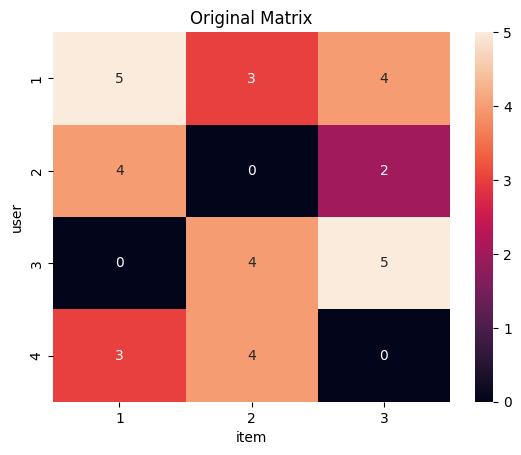

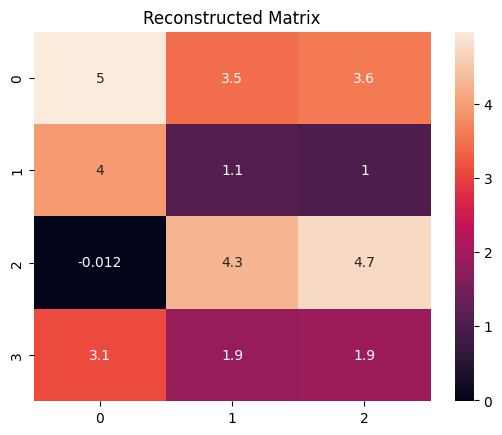

Recommended items for user 1: [0 2 1]


In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.DataFrame({
    'user': [1,1,1,2,2,3,3,4,4],
    'item': [1,2,3,1,3,2,3,1,2],
    'rating': [5,3,4,4,2,4,5,3,4]
})

matrix = ratings.pivot(index='user', columns='item', values='rating').fillna(0)

svd = TruncatedSVD(n_components=2)
matrix_reduced = svd.fit_transform(matrix)
matrix_reconstructed = np.dot(matrix_reduced, svd.components_)

rmse = np.sqrt(mean_squared_error(matrix, matrix_reconstructed))
print("RMSE:", rmse)

sns.heatmap(matrix, annot=True)
plt.title("Original Matrix")
plt.show()

sns.heatmap(matrix_reconstructed, annot=True)
plt.title("Reconstructed Matrix")
plt.show()

user_id = 1
predicted_ratings = matrix_reconstructed[user_id-1]
recommended_items = np.argsort(-predicted_ratings)

print("Recommended items for user 1:", recommended_items)

SCENARIO 2 – NMF Recommendation (Colab Code)

RMSE: 0.9539889569062577


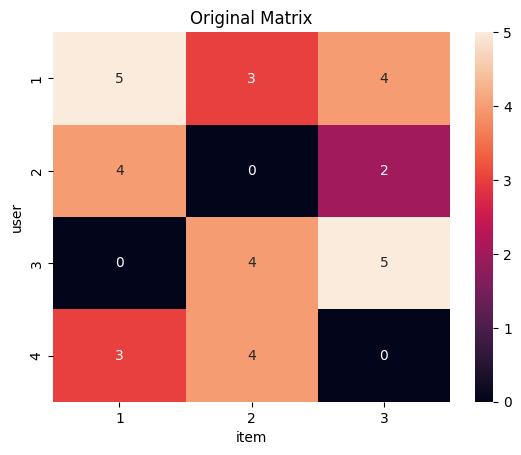

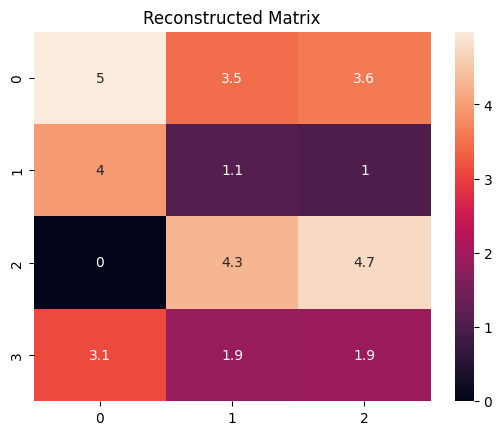

Recommended items for user 1: [0 2 1]


In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.DataFrame({
    'user': [1,1,1,2,2,3,3,4,4],
    'item': [1,2,3,1,3,2,3,1,2],
    'rating': [5,3,4,4,2,4,5,3,4]
})

matrix = ratings.pivot(index='user', columns='item', values='rating').fillna(0)

nmf = NMF(n_components=2, init='random', random_state=42)
W = nmf.fit_transform(matrix)
H = nmf.components_

matrix_reconstructed = np.dot(W, H)

rmse = np.sqrt(mean_squared_error(matrix, matrix_reconstructed))
print("RMSE:", rmse)

sns.heatmap(matrix, annot=True)
plt.title("Original Matrix")
plt.show()

sns.heatmap(matrix_reconstructed, annot=True)
plt.title("Reconstructed Matrix")
plt.show()

user_id = 1
predicted_ratings = matrix_reconstructed[user_id-1]
recommended_items = np.argsort(-predicted_ratings)

print("Recommended items for user 1:", recommended_items)